In [1]:
import matplotlib.patches as mpatches
from matplotlib.ticker import MaxNLocator
import tkinter as tk
from tkinter import filedialog, messagebox
import pandas as pd
config = {'method': 'Bonferroni', 'alpha': 0.05, 'logFC_threshold': 1, 'up_or_down_or_both': 'both_up_and_down_regulated', 'highlight_genes': [], 'top_genes': 20, 'upreg_criteria': None, 'downreg_criteria': None, 'upregulated_color': '#FF0000', 'downregulated_color': '#0000FF', 'not_significant_color': '#808080', 'not_significant_between_logFC_threshold_color': '#A0A0A0', 'pie_chart_size': 0.2, 'pie_chart_position': (0.85, 0.85), 'ranking_method': 'MAS', 'Magnitude (M)': 0, 'Altitude (A)': 1, 'g100': (-1, 0.2), 'g010': (1, 0.24), 'g001': (-0.4, -0.5), 'g110': (-0.6, 0.24), 'g101': (-0.8, -0.3), 'g011': (0.7, -0.1), 'g111': (0.4, -0.6)}

def volcano_plot_no_visualization(df, title, M=config['Magnitude (M)'], A=config['Altitude (A)'], method=config['method'], alpha=config['alpha'], logFC_threshold=config['logFC_threshold'], highlight_genes=config['highlight_genes'], top_genes=config['top_genes'], upreg_criteria=config['upreg_criteria'], downreg_criteria=config['downreg_criteria'], upregulated_color=config['upregulated_color'], downregulated_color=config['downregulated_color'], not_significant_color=config['not_significant_color'], not_significant_between_logFC_threshold_color=config['not_significant_between_logFC_threshold_color'], pie_chart_size=config['pie_chart_size'], pie_chart_position=config['pie_chart_position'], ranking_method=config['ranking_method'], up_or_down_or_both=config['up_or_down_or_both'], g100=config['g100'], g010=config['g010'], g001=config['g001'], g110=config['g110'], g101=config['g101'], g011=config['g011'], g111=config['g111']):
    method_to_column = {'PValue': 'PValue', 'BH': 'BH_adjusted_p-value', 'Bonferroni': 'Bonferroni_adjusted_p-value', 'BY': 'BY_adjusted_p-value', 'Holm': 'Holm_adjusted_p-value', 'Hochberg': 'Hochberg_adjusted_p-value', 'adjusted_p-value': 'adjusted_p-value'}
    if ranking_method not in ['Corner', 'MAS']:
        raise ValueError("Invalid ranking_method. Valid options are 'corner' and 'MAS'")
    if ranking_method == 'Corner':
        ranked_df = Corner_ranking(df, method=method, alpha=alpha)
    else:
        ranked_df = MAS(df, M=M, A=A, method=method, alpha=alpha, logFC_threshold=logFC_threshold, up_or_down_or_both=up_or_down_or_both)
    y_column = method_to_column[method]
    ranked_df['-log10(P)'] = -np.log10(ranked_df[y_column])
    if method == 'Bonferroni':
        adjusted_alpha = alpha
    else:
        adjusted_alpha = alpha
    significance_threshold = -np.log10(adjusted_alpha)
    if up_or_down_or_both == 'Only_upregulated':
        significant_genes_criteria = (df['logFC'] > logFC_threshold) & (df[y_column] <= adjusted_alpha)
    elif up_or_down_or_both == 'Only_downregulated':
        significant_genes_criteria = (df['logFC'] < -logFC_threshold) & (df[y_column] <= adjusted_alpha)
    elif up_or_down_or_both == 'both_up_and_down_regulated':
        significant_genes_criteria = (df['logFC'].abs() > logFC_threshold) & (df[y_column] <= adjusted_alpha)
    significant_genes = df[significant_genes_criteria]
    ranked_df['Category'] = 'Not Significant'
    ranked_df.loc[ranked_df.apply(lambda row: row['logFC'] >= logFC_threshold and row[y_column] <= adjusted_alpha, axis=1), 'Category'] = 'Upregulated'
    ranked_df.loc[ranked_df.apply(lambda row: row['logFC'] <= -logFC_threshold and row[y_column] <= adjusted_alpha, axis=1), 'Category'] = 'Downregulated'
    upreg_criteria = upreg_criteria if upreg_criteria is not None else lambda row: row[y_column] <= adjusted_alpha and row['logFC'] >= logFC_threshold
    downreg_criteria = downreg_criteria if downreg_criteria is not None else lambda row: row[y_column] <= adjusted_alpha and row['logFC'] <= -logFC_threshold
    ranked_df['Category'] = 'Not Significant'
    ranked_df.loc[ranked_df.apply(upreg_criteria, axis=1), 'Category'] = 'Upregulated'
    ranked_df.loc[ranked_df.apply(downreg_criteria, axis=1), 'Category'] = 'Downregulated'
    colors = {'Upregulated': upregulated_color, 'Downregulated': downregulated_color, 'Not Significant': not_significant_color, 'Not Significant Between LogFC Threshold': not_significant_between_logFC_threshold_color}
    all_genes = ranked_df[ranked_df['Category'] != 'Not Significant Between LogFC Threshold']
    not_sig_between_genes = ranked_df[ranked_df['Category'] == 'Not Significant Between LogFC Threshold']
    method = config['method']
    ranking_method = config['ranking_method']
    if up_or_down_or_both == 'Only_upregulated':
        significance_criteria = (ranked_df['logFC'] > logFC_threshold) & (ranked_df[y_column] <= adjusted_alpha)
    elif up_or_down_or_both == 'Only_downregulated':
        significance_criteria = (ranked_df['logFC'] < -logFC_threshold) & (ranked_df[y_column] <= adjusted_alpha)
    elif up_or_down_or_both == 'both_up_and_down_regulated':
        significance_criteria = (ranked_df['logFC'].abs() > logFC_threshold) & (ranked_df[y_column] <= adjusted_alpha)
    significant = sum(significance_criteria)
    insignificant = len(ranked_df) - significant
    sizes = [significant, insignificant]
    labels = [f'Significant ({significant}) - {significant / len(ranked_df):.1%}', f'Insignificant ({insignificant}) - {insignificant / len(ranked_df):.1%}']
    labels2 = [f'', f'']
    colors = ['lightgreen', 'gray']
    output_columns = ['Gene Symbol', 'logFC', 'PValue', y_column]
    if ranking_method == 'Corner':
        output_columns += ['corner_rank', 'corner_distance']
    elif ranking_method == 'MAS':
        output_columns += ['MAS_rank', 'MAS_Score']
    output_df = ranked_df[output_columns]
    output_df = output_df.rename(columns={y_column: method})
    ranked_df['Category'] = 'Insignificant'
    ranked_df.loc[significance_criteria & (ranked_df['logFC'] > 0), 'Category'] = 'Upregulated'
    ranked_df.loc[significance_criteria & (ranked_df['logFC'] < 0), 'Category'] = 'Downregulated'
    significant_genes = ranked_df[ranked_df['Category'].isin(['Upregulated', 'Downregulated'])]
    if ranking_method == 'MAS':
        significant_genes = significant_genes.sort_values(by='MAS_Score', ascending=False).reset_index(drop=True)
        significant_genes['MAS_rank'] = significant_genes.index + 1
    else:
        x_max = df['logFC'].max()
        x_min = df['logFC'].min()
        maximum_x = max(abs(x_min), abs(x_max))
        y_max = ranked_df['-log10(P)'].max()

        def calculate_distance(row):
            x = row['logFC']
            y = row['-log10(P)']
            if x >= 0:
                return np.sqrt((x - maximum_x) ** 2 + (y - y_max) ** 2)
            else:
                return np.sqrt((x + maximum_x) ** 2 + (y - y_max) ** 2)
        significant_genes['corner_distance'] = significant_genes.apply(calculate_distance, axis=1)
        significant_genes = significant_genes.sort_values(by='corner_distance').reset_index(drop=True)
        significant_genes['corner_rank'] = significant_genes.index + 1
    return (output_df, significant_genes)
import numpy as np

def MAS(df, M, A, method, alpha, logFC_threshold, up_or_down_or_both):
    if method == 'PValue':
        y_column = 'PValue'
    elif method == 'BH':
        df['BH_adjusted_p-value'] = BH_adjusted_pvalue(df['PValue'].values, alpha)
        y_column = 'BH_adjusted_p-value'
    elif method == 'Bonferroni':
        n_tests = len(df)
        df['Bonferroni_adjusted_p-value'] = np.minimum(df['PValue'] * n_tests, 1.0)
        y_column = 'Bonferroni_adjusted_p-value'
    elif method == 'BY':
        df['BY_adjusted_p-value'] = BY_adjusted_pvalue(df['PValue'].values, alpha)
        y_column = 'BY_adjusted_p-value'
    elif method == 'Holm':
        df['Holm_adjusted_p-value'] = Holm_adjusted_pvalue(df['PValue'].values, alpha)
        y_column = 'Holm_adjusted_p-value'
    elif method == 'Hochberg':
        df['Hochberg_adjusted_p-value'] = Hochberg_adjusted_pvalue(df['PValue'].values, alpha)
        y_column = 'Hochberg_adjusted_p-value'
    else:
        y_column = 'PValue'
    df[y_column] = df[y_column].clip(upper=1)
    adjusted_alpha = alpha / len(df) if method == 'Bonferroni' else alpha
    if up_or_down_or_both == 'Only_upregulated':
        df['MAS_Score'] = np.where((df['logFC'] > logFC_threshold) & (df[y_column] <= adjusted_alpha), np.abs(df['logFC']) ** M * np.abs(-np.log10(df[y_column])) ** A, 0)
    elif up_or_down_or_both == 'Only_downregulated':
        df['MAS_Score'] = np.where((df['logFC'] < -logFC_threshold) & (df[y_column] <= adjusted_alpha), np.abs(df['logFC']) ** M * np.abs(-np.log10(df[y_column])) ** A, 0)
    elif up_or_down_or_both == 'both_up_and_down_regulated':
        df['MAS_Score'] = np.where((df['logFC'].abs() > logFC_threshold) & (df[y_column] <= adjusted_alpha), np.abs(df['logFC']) ** M * np.abs(-np.log10(df[y_column])) ** A, 0)
    df = df.sort_values(by='MAS_Score', ascending=False).reset_index(drop=True)
    df['MAS_rank'] = df.index + 1
    return df

def BH_adjusted_pvalue(p, alpha):
    sort = np.argsort(p)
    rank = np.zeros(len(p))
    j = 1
    for i in range(len(sort)):
        rank[sort[i]] = j
        j = j + 1
    new_alpha = rank / len(p) * alpha
    L = []
    for j in range(len(rank)):
        if p[np.where(rank == len(rank) - j)[0][0]] < new_alpha[np.where(rank == len(rank) - j)[0][0]]:
            L.append(np.where(rank == len(rank) - j)[0][0])
    new_p = p * (len(p) / rank)
    H = np.zeros(len(p))
    H[np.where(rank == len(p))[0][0]] = new_p[np.where(rank == len(p))[0][0]]
    for k in range(1, len(p)):
        if new_p[np.where(rank == len(p) - k)[0][0]] > new_p[np.where(rank == len(p) - k + 1)[0][0]]:
            H[np.where(rank == len(p) - k)[0][0]] = new_p[np.where(rank == len(p) - k + 1)[0][0]]
        else:
            H[np.where(rank == len(p) - k)[0][0]] = new_p[np.where(rank == len(p) - k)[0][0]]
    BH_adjusted_p_values = np.where(H > 1, 1, H)
    return BH_adjusted_p_values
from matplotlib.ticker import MaxNLocator
import numpy as np
import matplotlib.pyplot as plt

def annotate_bars_vertical_with_totals(ax, positions, top_genes_up, top_genes_down, up_counts, down_counts, width):
    vertical_offset = 0.25
    total_offset = 0.3
    bbox_props = dict(boxstyle='round,pad=0.3', fc='seashell', ec='black', lw=1)
    for i, position in enumerate(positions):
        down_text = '\n'.join(top_genes_down[f'BH'])
        ax.text(position + width / 2, vertical_offset, down_text, ha='center', va='bottom', fontsize=22, color='black', rotation=0, transform=ax.get_xaxis_transform(), bbox=bbox_props)
        up_text = '\n'.join(top_genes_up[f'BH'])
        ax.text(position - width / 2, vertical_offset, up_text, ha='center', va='bottom', fontsize=22, color='black', rotation=0, transform=ax.get_xaxis_transform(), bbox=bbox_props)
        ax.text(position - width / 2, total_offset, f'Total: {down_counts[i]}', ha='center', va='bottom', fontsize=22, color='black', rotation=0)
        ax.text(position + width / 2, total_offset, f'Total: {up_counts[i]}', ha='center', va='bottom', fontsize=22, color='black', rotation=0)


In [2]:
data = pd.read_csv('GSE231693-Ready.csv')
data.set_index('Gene Symbol', inplace=True)


In [3]:
groups = ['Normal', 'IPF']
group_dfs = {}
for group in groups:
    matching_cols = [col for col in data.columns if col.startswith(group)]
    group_dfs[group] = data[matching_cols]
Normal_df = group_dfs['Normal']
IPF_df = group_dfs['IPF']


In [4]:
Normal_IPF = pd.concat([Normal_df, IPF_df], axis=1)


In [5]:
import subprocess

def run_r_script():
    command = ['Rscript', 'TMM_GLMQL.R']
    result = subprocess.run(command, stdout=subprocess.PIPE, stderr=subprocess.PIPE, universal_newlines=True)
    if result.stdout:
        print('R script output:', result.stdout)
    if result.stderr:
        print('R script errors:', result.stderr)
if __name__ == '__main__':
    run_r_script()


R script output: [1] "Starting script execution."
[1] "Script has started running."
[1] "Guideline"
Script continues...
[1] "An error occurred: file choice cancelled"

R script errors: Loading required package: limma
Warning message:
package 'rstudioapi' was built under R version 4.3.3 



In [6]:
import glob
import pandas as pd
import os

def read_csv_files_to_dict(directory):
    pattern = os.path.join(directory, 'EdgeR_Normal_*.csv')
    csv_files = glob.glob(pattern)
    if not csv_files:
        print('No matching files found in the directory.')
        return {}
    dataframes_dict = {}
    for file in csv_files:
        try:
            file_name = os.path.splitext(os.path.basename(file))[0]
            df = pd.read_csv(file)
            globals()[file_name] = df
            dataframes_dict[file_name] = df
            print(f'Loaded DataFrame: {file_name} from {file}')
        except Exception as e:
            print(f'Error reading file {file}: {e}')
    return dataframes_dict
if __name__ == '__main__':
    current_directory = './'
    dataframes = read_csv_files_to_dict(current_directory)
    print('\nAccessing DataFrames:')
    for file_name, df in dataframes.items():
        print(f'\nDataFrame: {file_name}')
        print(df.head())


Loaded DataFrame: EdgeR_Normal_vs_IPF from .\EdgeR_Normal_vs_IPF.csv

Accessing DataFrames:

DataFrame: EdgeR_Normal_vs_IPF
  GeneSymbol     logFC    logCPM           F        PValue           FDR  \
0      MYO3B  3.964024 -0.103861  212.336005  3.328636e-20  6.459552e-16   
1   ADAMTS19  4.204560 -0.418104  109.808338  1.957016e-15  1.535627e-11   
2      FNDC1  4.372611  3.796045  158.395961  2.373947e-15  1.535627e-11   
3     COL9A1  3.840230 -0.946259   96.742363  1.349499e-14  6.547092e-11   
4        RET  2.455140  1.305963  136.079887  2.765083e-14  9.581225e-11   

   Bonferroni_pvalue  
0       6.459552e-16  
1       3.797786e-11  
2       4.606882e-11  
3       2.618837e-10  
4       5.365921e-10  


C:\Users\13367\AppData\Local\Temp\ipykernel_16368\1814582185.py:37: UserWarning: Setting the 'color' property will override the edgecolor or facecolor properties.
  upregulated_patch = mpatches.Patch(color='pink', label='Upregulated', edgecolor='black', alpha=0.6)
C:\Users\13367\AppData\Local\Temp\ipykernel_16368\1814582185.py:38: UserWarning: Setting the 'color' property will override the edgecolor or facecolor properties.
  downregulated_patch = mpatches.Patch(color='lightblue', label='Downregulated', edgecolor='black', alpha=0.6)


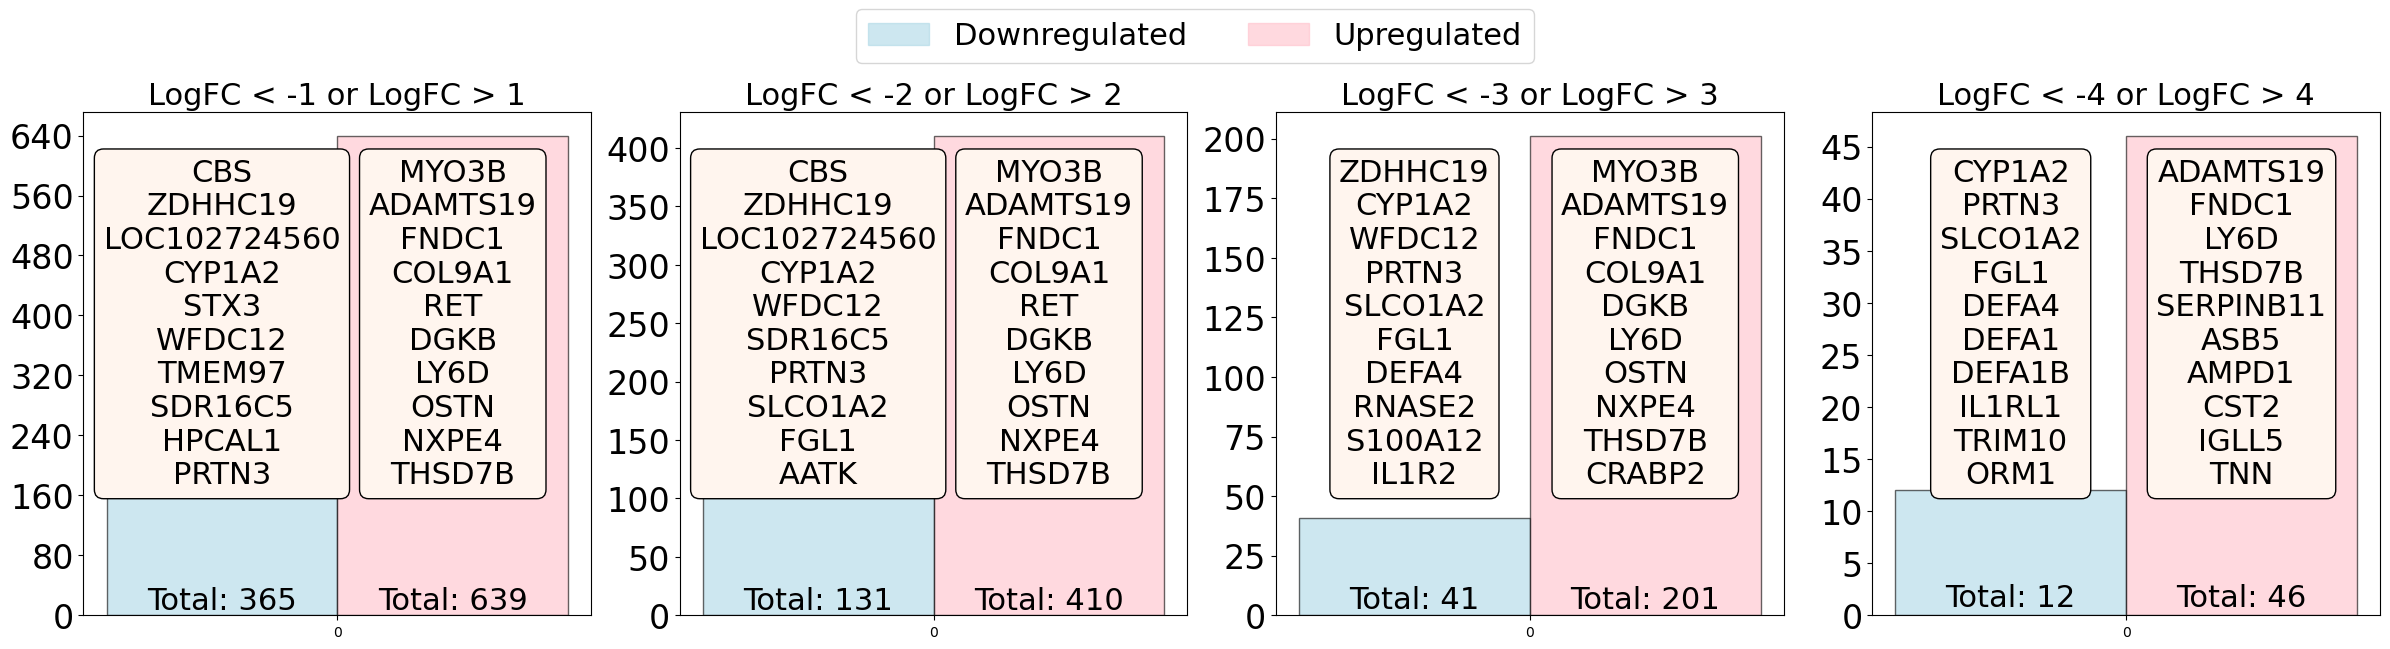

In [7]:
Data = dataframes['EdgeR_Normal_vs_IPF']
Data.rename(columns={'GeneSymbol': 'Gene Symbol'}, inplace=True)
title = 'EdgeR_Normal_vs_IPF'
config_Upset = {'method': 'Bonferroni', 'alpha': 0.05, 'logFC_threshold': 1, 'up_or_down_or_both': 'both_up_and_down_regulated', 'highlight_genes': [], 'top_genes': 20, 'upreg_criteria': None, 'downreg_criteria': None, 'upregulated_color': '#FF0000', 'downregulated_color': '#0000FF', 'not_significant_color': '#808080', 'not_significant_between_logFC_threshold_color': '#A0A0A0', 'pie_chart_size': 0.2, 'pie_chart_position': (0.85, 0.85), 'ranking_method': 'MAS', 'Magnitude (M)': 0, 'Altitude (A)': 1, 'g100': (-1, 0.2), 'g010': (1, 0.24), 'g001': (-0.4, -0.5), 'g110': (-0.6, 0.24), 'g101': (-0.8, -0.3), 'g011': (0.7, -0.1), 'g111': (0.4, -0.6)}
AllGenes_DE_HLTY_vs_SARS_CoV_2, Significant_DE_HLTY_vs_SARS_CoV_2 = volcano_plot_no_visualization(Data, M=config_Upset['Magnitude (M)'], A=config_Upset['Altitude (A)'], title=title, method=config_Upset['method'], alpha=config_Upset['alpha'], logFC_threshold=config_Upset['logFC_threshold'], highlight_genes=config_Upset['highlight_genes'], top_genes=config_Upset['top_genes'], upreg_criteria=config_Upset['upreg_criteria'], downreg_criteria=config_Upset['downreg_criteria'], upregulated_color=config_Upset['upregulated_color'], downregulated_color=config_Upset['downregulated_color'], not_significant_color=config_Upset['not_significant_color'], not_significant_between_logFC_threshold_color=config_Upset['not_significant_between_logFC_threshold_color'], pie_chart_size=config_Upset['pie_chart_size'], pie_chart_position=config_Upset['pie_chart_position'], ranking_method=config_Upset['ranking_method'], up_or_down_or_both=config_Upset['up_or_down_or_both'], g100=config_Upset['g100'], g010=config_Upset['g010'], g001=config_Upset['g001'], g110=config_Upset['g110'], g101=config_Upset['g101'], g011=config_Upset['g011'], g111=config_Upset['g111'])
config = {'method': 'Bonferroni', 'alpha': 0.05, 'logFC_threshold': 1, 'up_or_down_or_both': 'both_up_and_down_regulated', 'highlight_genes': [], 'top_genes': 20, 'upreg_criteria': None, 'downreg_criteria': None, 'upregulated_color': '#FF0000', 'downregulated_color': '#0000FF', 'not_significant_color': '#808080', 'not_significant_between_logFC_threshold_color': '#A0A0A0', 'pie_chart_size': 0.2, 'pie_chart_position': (0.85, 0.85), 'ranking_method': 'MAS', 'Magnitude (M)': 0, 'Altitude (A)': 1, 'g100': (-1, 0.2), 'g010': (1, 0.24), 'g001': (-0.4, -0.5), 'g110': (-0.6, 0.24), 'g101': (-0.8, -0.3), 'g011': (0.7, -0.1), 'g111': (0.4, -0.6)}
logFC_threshold_values = range(1, 5)
fig, axs = plt.subplots(1, 4, figsize=(24, 6))
axs = axs.flatten()
title_font = {'family': 'serif', 'color': 'darkred', 'weight': 'bold', 'size': 24}
label_font = {'family': 'arial', 'color': 'navy', 'weight': 'bold', 'size': 24}
title_font2 = {'family': 'serif', 'color': 'black', 'size': 24}
for idx, logFC_threshold in enumerate(logFC_threshold_values):
    ax = axs[idx]
    config['logFC_threshold'] = logFC_threshold
    AllGenes, Significant = volcano_plot_no_visualization(Data, M=config['Magnitude (M)'], A=config['Altitude (A)'], title=title, method=config['method'], alpha=config['alpha'], logFC_threshold=config['logFC_threshold'], highlight_genes=config['highlight_genes'], top_genes=config['top_genes'], upreg_criteria=config['upreg_criteria'], downreg_criteria=config['downreg_criteria'], upregulated_color=config['upregulated_color'], downregulated_color=config['downregulated_color'], not_significant_color=config['not_significant_color'], not_significant_between_logFC_threshold_color=config['not_significant_between_logFC_threshold_color'], pie_chart_size=config['pie_chart_size'], pie_chart_position=config['pie_chart_position'], ranking_method=config['ranking_method'], up_or_down_or_both=config['up_or_down_or_both'], g100=config['g100'], g010=config['g010'], g001=config['g001'], g110=config['g110'], g101=config['g101'], g011=config['g011'], g111=config['g111'])
    upregulated_counts = Significant[Significant['Category'] == 'Upregulated'].shape[0]
    downregulated_counts = Significant[Significant['Category'] == 'Downregulated'].shape[0]
    positions = np.arange(1)
    width = 1
    ax.bar(positions - width / 2, downregulated_counts, width, label='Downregulated', color='lightblue', edgecolor='black', alpha=0.6)
    ax.bar(positions + width / 2, upregulated_counts, width, label='Upregulated', color='pink', edgecolor='black', alpha=0.6)
    if logFC_threshold == 0:
        title = f'LogFC < {logFC_threshold} or LogFC > {logFC_threshold}'
    else:
        title = f'LogFC < -{logFC_threshold} or LogFC > {logFC_threshold}'
    ax.set_title(title, fontsize=22)
    ax.set_xticks(positions)
    ax.yaxis.set_major_locator(MaxNLocator(integer=True))
    ax.tick_params(axis='y', labelsize=24)
    top_10_down_genes = {'BH': Significant[Significant['logFC'] < 0].head(10)['Gene Symbol'].tolist()}
    top_10_up_genes = {'BH': Significant[Significant['logFC'] > 0].head(10)['Gene Symbol'].tolist()}
    summary_stats = {'BH': {'Total': Significant.shape[0], 'Upregulated': Significant[Significant['Category'] == 'Upregulated'].shape[0], 'Downregulated': Significant[Significant['Category'] == 'Downregulated'].shape[0]}}
    upregulated_counts = [summary_stats[obj]['Upregulated'] for obj in summary_stats]
    downregulated_counts = [summary_stats[obj]['Downregulated'] for obj in summary_stats]
    annotate_bars_vertical_with_totals(ax, positions, top_10_down_genes, top_10_up_genes, upregulated_counts, downregulated_counts, width)
upregulated_patch = mpatches.Patch(color='pink', label='Upregulated', edgecolor='black', alpha=0.6)
downregulated_patch = mpatches.Patch(color='lightblue', label='Downregulated', edgecolor='black', alpha=0.6)
fig.legend(handles=[downregulated_patch, upregulated_patch], loc='upper center', ncol=2, bbox_to_anchor=(0.5, 1.1), fontsize=22)
plt.tight_layout(rect=[0, 0, 1, 0.98])
plt.show()
Bonferroni_Upregulated = Significant_DE_HLTY_vs_SARS_CoV_2[Significant_DE_HLTY_vs_SARS_CoV_2['logFC'] > 1]
Bonferroni_Downregulated = Significant_DE_HLTY_vs_SARS_CoV_2[Significant_DE_HLTY_vs_SARS_CoV_2['logFC'] < -1]
Bonferroni_Significant = Significant_DE_HLTY_vs_SARS_CoV_2.copy()
Bonferroni_Upregulated.to_csv('EdgeR_Upregulated_IPF.csv', index=False)
Bonferroni_Downregulated.to_csv('EdgeR_Downregulated_IPF.csv', index=False)
Bonferroni_Significant.to_csv('EdgeR_Significant_IPF.csv', index=False)


In [8]:
import glob
import pandas as pd
import os

def read_csv_files_to_dict(directory):
    pattern = os.path.join(directory, 'EdgeR_Significant_*.csv')
    csv_files = glob.glob(pattern)
    if not csv_files:
        print('No matching files found in the directory.')
        return {}
    dataframes_dict = {}
    for file in csv_files:
        try:
            file_name = os.path.splitext(os.path.basename(file))[0]
            df = pd.read_csv(file)
            globals()[file_name] = df
            dataframes_dict[file_name] = df
            print(f'Loaded DataFrame: {file_name} from {file}')
        except Exception as e:
            print(f'Error reading file {file}: {e}')
    return dataframes_dict
if __name__ == '__main__':
    current_directory = './'
    ranked_dataframes = read_csv_files_to_dict(current_directory)
    print('\nAccessing DataFrames:')
    for file_name, df in ranked_dataframes.items():
        print(f'\nDataFrame: {file_name}')
        print(df.head())


Loaded DataFrame: EdgeR_Significant_IPF from .\EdgeR_Significant_IPF.csv

Accessing DataFrames:

DataFrame: EdgeR_Significant_IPF
  Gene Symbol     logFC    logCPM           F        PValue           FDR  \
0       MYO3B  3.964024 -0.103861  212.336005  3.328636e-20  6.459552e-16   
1    ADAMTS19  4.204560 -0.418104  109.808338  1.957016e-15  1.535627e-11   
2       FNDC1  4.372611  3.796045  158.395961  2.373947e-15  1.535627e-11   
3      COL9A1  3.840230 -0.946259   96.742363  1.349499e-14  6.547092e-11   
4         RET  2.455140  1.305963  136.079887  2.765083e-14  9.581225e-11   

   Bonferroni_pvalue  Bonferroni_adjusted_p-value  MAS_Score  MAS_rank  \
0       6.459552e-16                 6.459552e-16  15.189798         1   
1       3.797786e-11                 3.797786e-11  10.420469         2   
2       4.606882e-11                 4.606882e-11  10.336593         3   
3       2.618837e-10                 2.618837e-10   9.581892         4   
4       5.365921e-10                 

In [ ]:
import subprocess

def run_r_script():
    command = ['Rscript', 'DESeq2.R']
    result = subprocess.run(command, stdout=subprocess.PIPE, stderr=subprocess.PIPE, universal_newlines=True)
    if result.stdout:
        print('R script output:', result.stdout)
    if result.stderr:
        print('R script errors:', result.stderr)
if __name__ == '__main__':
    run_r_script()


In [10]:
import glob
import pandas as pd
import os

def read_csv_files_to_dict(directory):
    pattern = os.path.join(directory, 'DESeq2_Normal*_vs_*.csv')
    csv_files = glob.glob(pattern)
    if not csv_files:
        print('No matching files found in the directory.')
        return {}
    dataframes_dict = {}
    for file in csv_files:
        try:
            file_name = os.path.splitext(os.path.basename(file))[0]
            df = pd.read_csv(file)
            globals()[file_name] = df
            dataframes_dict[file_name] = df
            print(f'Loaded DataFrame: {file_name} from {file}')
        except Exception as e:
            print(f'Error reading file {file}: {e}')
    return dataframes_dict
if __name__ == '__main__':
    current_directory = './'
    dataframes = read_csv_files_to_dict(current_directory)
    print('\nAccessing DataFrames:')
    for file_name, df in dataframes.items():
        print(f'\nDataFrame: {file_name}')
        print(df.head())


Loaded DataFrame: DESeq2_Normal_vs_IPF_with_FDR_and_Bonferroni from .\DESeq2_Normal_vs_IPF_with_FDR_and_Bonferroni.csv

Accessing DataFrames:

DataFrame: DESeq2_Normal_vs_IPF_with_FDR_and_Bonferroni
  GeneSymbol    baseMean     logFC     lfcSE       stat        PValue  \
0      FNDC1  380.719167  4.396912  0.322125  13.649698  2.027180e-42   
1      MYO3B   23.593916  4.045672  0.323875  12.491442  8.313351e-36   
2        RET   66.268664  2.488299  0.207097  12.015133  2.958943e-33   
3      HPSE2  368.771757  3.979937  0.344138  11.564929  6.204248e-31   
4     CRABP2  308.988247  3.129624  0.273655  11.436381  2.751253e-30   

            FDR  Bonferroni_pvalue  
0  3.700211e-38       3.849411e-38  
1  7.587180e-32       1.578622e-31  
2  1.800319e-29       5.618736e-29  
3  2.831153e-27       1.178125e-26  
4  1.004372e-26       5.224354e-26  


C:\Users\13367\AppData\Local\Temp\ipykernel_16368\690421022.py:37: UserWarning: Setting the 'color' property will override the edgecolor or facecolor properties.
  upregulated_patch = mpatches.Patch(color='pink', label='Upregulated', edgecolor='black', alpha=0.6)
C:\Users\13367\AppData\Local\Temp\ipykernel_16368\690421022.py:38: UserWarning: Setting the 'color' property will override the edgecolor or facecolor properties.
  downregulated_patch = mpatches.Patch(color='lightblue', label='Downregulated', edgecolor='black', alpha=0.6)


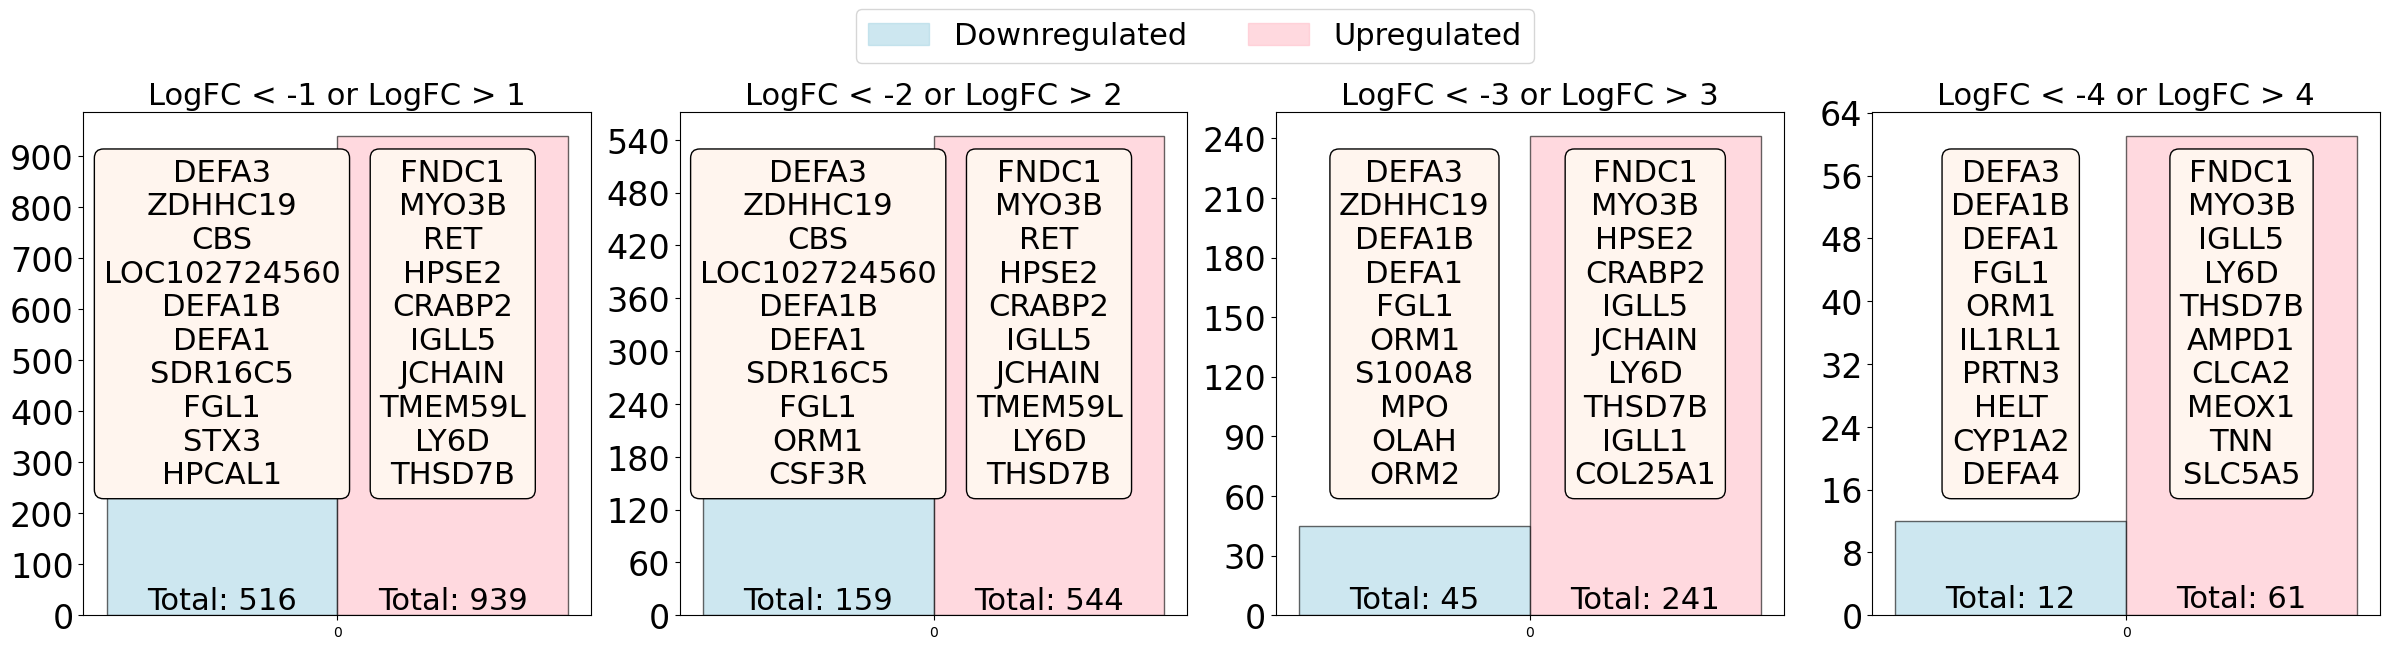

In [11]:
Data = dataframes['DESeq2_Normal_vs_IPF_with_FDR_and_Bonferroni']
Data.rename(columns={'GeneSymbol': 'Gene Symbol'}, inplace=True)
title = 'DESeq2_Normal_vs_IPF_with_FDR_and_Bonferroni'
config_Upset = {'method': 'Bonferroni', 'alpha': 0.05, 'logFC_threshold': 1, 'up_or_down_or_both': 'both_up_and_down_regulated', 'highlight_genes': [], 'top_genes': 20, 'upreg_criteria': None, 'downreg_criteria': None, 'upregulated_color': '#FF0000', 'downregulated_color': '#0000FF', 'not_significant_color': '#808080', 'not_significant_between_logFC_threshold_color': '#A0A0A0', 'pie_chart_size': 0.2, 'pie_chart_position': (0.85, 0.85), 'ranking_method': 'MAS', 'Magnitude (M)': 0, 'Altitude (A)': 1, 'g100': (-1, 0.2), 'g010': (1, 0.24), 'g001': (-0.4, -0.5), 'g110': (-0.6, 0.24), 'g101': (-0.8, -0.3), 'g011': (0.7, -0.1), 'g111': (0.4, -0.6)}
AllGenes_DE_HLTY_vs_SARS_CoV_2, Significant_DE_HLTY_vs_SARS_CoV_2 = volcano_plot_no_visualization(Data, M=config_Upset['Magnitude (M)'], A=config_Upset['Altitude (A)'], title=title, method=config_Upset['method'], alpha=config_Upset['alpha'], logFC_threshold=config_Upset['logFC_threshold'], highlight_genes=config_Upset['highlight_genes'], top_genes=config_Upset['top_genes'], upreg_criteria=config_Upset['upreg_criteria'], downreg_criteria=config_Upset['downreg_criteria'], upregulated_color=config_Upset['upregulated_color'], downregulated_color=config_Upset['downregulated_color'], not_significant_color=config_Upset['not_significant_color'], not_significant_between_logFC_threshold_color=config_Upset['not_significant_between_logFC_threshold_color'], pie_chart_size=config_Upset['pie_chart_size'], pie_chart_position=config_Upset['pie_chart_position'], ranking_method=config_Upset['ranking_method'], up_or_down_or_both=config_Upset['up_or_down_or_both'], g100=config_Upset['g100'], g010=config_Upset['g010'], g001=config_Upset['g001'], g110=config_Upset['g110'], g101=config_Upset['g101'], g011=config_Upset['g011'], g111=config_Upset['g111'])
config = {'method': 'Bonferroni', 'alpha': 0.05, 'logFC_threshold': 1, 'up_or_down_or_both': 'both_up_and_down_regulated', 'highlight_genes': [], 'top_genes': 20, 'upreg_criteria': None, 'downreg_criteria': None, 'upregulated_color': '#FF0000', 'downregulated_color': '#0000FF', 'not_significant_color': '#808080', 'not_significant_between_logFC_threshold_color': '#A0A0A0', 'pie_chart_size': 0.2, 'pie_chart_position': (0.85, 0.85), 'ranking_method': 'MAS', 'Magnitude (M)': 0, 'Altitude (A)': 1, 'g100': (-1, 0.2), 'g010': (1, 0.24), 'g001': (-0.4, -0.5), 'g110': (-0.6, 0.24), 'g101': (-0.8, -0.3), 'g011': (0.7, -0.1), 'g111': (0.4, -0.6)}
logFC_threshold_values = range(1, 5)
fig, axs = plt.subplots(1, 4, figsize=(24, 6))
axs = axs.flatten()
title_font = {'family': 'serif', 'color': 'darkred', 'weight': 'bold', 'size': 24}
label_font = {'family': 'arial', 'color': 'navy', 'weight': 'bold', 'size': 24}
title_font2 = {'family': 'serif', 'color': 'black', 'size': 24}
for idx, logFC_threshold in enumerate(logFC_threshold_values):
    ax = axs[idx]
    config['logFC_threshold'] = logFC_threshold
    AllGenes, Significant = volcano_plot_no_visualization(Data, M=config['Magnitude (M)'], A=config['Altitude (A)'], title=title, method=config['method'], alpha=config['alpha'], logFC_threshold=config['logFC_threshold'], highlight_genes=config['highlight_genes'], top_genes=config['top_genes'], upreg_criteria=config['upreg_criteria'], downreg_criteria=config['downreg_criteria'], upregulated_color=config['upregulated_color'], downregulated_color=config['downregulated_color'], not_significant_color=config['not_significant_color'], not_significant_between_logFC_threshold_color=config['not_significant_between_logFC_threshold_color'], pie_chart_size=config['pie_chart_size'], pie_chart_position=config['pie_chart_position'], ranking_method=config['ranking_method'], up_or_down_or_both=config['up_or_down_or_both'], g100=config['g100'], g010=config['g010'], g001=config['g001'], g110=config['g110'], g101=config['g101'], g011=config['g011'], g111=config['g111'])
    upregulated_counts = Significant[Significant['Category'] == 'Upregulated'].shape[0]
    downregulated_counts = Significant[Significant['Category'] == 'Downregulated'].shape[0]
    positions = np.arange(1)
    width = 1
    ax.bar(positions - width / 2, downregulated_counts, width, label='Downregulated', color='lightblue', edgecolor='black', alpha=0.6)
    ax.bar(positions + width / 2, upregulated_counts, width, label='Upregulated', color='pink', edgecolor='black', alpha=0.6)
    if logFC_threshold == 0:
        title = f'LogFC < {logFC_threshold} or LogFC > {logFC_threshold}'
    else:
        title = f'LogFC < -{logFC_threshold} or LogFC > {logFC_threshold}'
    ax.set_title(title, fontsize=22)
    ax.set_xticks(positions)
    ax.yaxis.set_major_locator(MaxNLocator(integer=True))
    ax.tick_params(axis='y', labelsize=24)
    top_10_down_genes = {'BH': Significant[Significant['logFC'] < 0].head(10)['Gene Symbol'].tolist()}
    top_10_up_genes = {'BH': Significant[Significant['logFC'] > 0].head(10)['Gene Symbol'].tolist()}
    summary_stats = {'BH': {'Total': Significant.shape[0], 'Upregulated': Significant[Significant['Category'] == 'Upregulated'].shape[0], 'Downregulated': Significant[Significant['Category'] == 'Downregulated'].shape[0]}}
    upregulated_counts = [summary_stats[obj]['Upregulated'] for obj in summary_stats]
    downregulated_counts = [summary_stats[obj]['Downregulated'] for obj in summary_stats]
    annotate_bars_vertical_with_totals(ax, positions, top_10_down_genes, top_10_up_genes, upregulated_counts, downregulated_counts, width)
upregulated_patch = mpatches.Patch(color='pink', label='Upregulated', edgecolor='black', alpha=0.6)
downregulated_patch = mpatches.Patch(color='lightblue', label='Downregulated', edgecolor='black', alpha=0.6)
fig.legend(handles=[downregulated_patch, upregulated_patch], loc='upper center', ncol=2, bbox_to_anchor=(0.5, 1.1), fontsize=22)
plt.tight_layout(rect=[0, 0, 1, 0.98])
plt.show()
Bonferroni_Upregulated = Significant_DE_HLTY_vs_SARS_CoV_2[Significant_DE_HLTY_vs_SARS_CoV_2['logFC'] > 1]
Bonferroni_Downregulated = Significant_DE_HLTY_vs_SARS_CoV_2[Significant_DE_HLTY_vs_SARS_CoV_2['logFC'] < -1]
Bonferroni_Significant = Significant_DE_HLTY_vs_SARS_CoV_2.copy()
Bonferroni_Upregulated.to_csv('DESeq2_Upregulated_IPF.csv', index=False)
Bonferroni_Downregulated.to_csv('DESeq2_Downregulated_IPF.csv', index=False)
Bonferroni_Significant.to_csv('DESeq2_Significant_IPF.csv', index=False)


In [12]:
import glob
import pandas as pd
import os

def read_csv_files_to_dict(directory):
    pattern = os.path.join(directory, 'DESeq2_Significant_*.csv')
    csv_files = glob.glob(pattern)
    if not csv_files:
        print('No matching files found in the directory.')
        return {}
    dataframes_dict = {}
    for file in csv_files:
        try:
            file_name = os.path.splitext(os.path.basename(file))[0]
            df = pd.read_csv(file)
            globals()[file_name] = df
            dataframes_dict[file_name] = df
            print(f'Loaded DataFrame: {file_name} from {file}')
        except Exception as e:
            print(f'Error reading file {file}: {e}')
    return dataframes_dict
if __name__ == '__main__':
    current_directory = './'
    ranked_dataframes = read_csv_files_to_dict(current_directory)
    print('\nAccessing DataFrames:')
    for file_name, df in ranked_dataframes.items():
        print(f'\nDataFrame: {file_name}')
        print(df.head())


Loaded DataFrame: DESeq2_Significant_IPF from .\DESeq2_Significant_IPF.csv

Accessing DataFrames:

DataFrame: DESeq2_Significant_IPF
  Gene Symbol    baseMean     logFC     lfcSE       stat        PValue  \
0       FNDC1  380.719167  4.396912  0.322125  13.649698  2.027180e-42   
1       MYO3B   23.593916  4.045672  0.323875  12.491442  8.313351e-36   
2         RET   66.268664  2.488299  0.207097  12.015133  2.958943e-33   
3       HPSE2  368.771757  3.979937  0.344138  11.564929  6.204248e-31   
4      CRABP2  308.988247  3.129624  0.273655  11.436381  2.751253e-30   

            FDR  Bonferroni_pvalue  Bonferroni_adjusted_p-value  MAS_Score  \
0  3.700211e-38       3.849411e-38                 3.933945e-38  37.405172   
1  7.587180e-32       1.578622e-31                 1.613289e-31  30.792288   
2  1.800319e-29       5.618736e-29                 5.742124e-29  28.240927   
3  2.831153e-27       1.178125e-26                 1.203996e-26  25.919375   
4  1.004372e-26       5.224354e-

In [13]:
def analyze_gene_data(Data):
    import matplotlib.pyplot as plt
    import matplotlib.patches as mpatches
    import numpy as np
    from matplotlib.ticker import MaxNLocator
    Data.rename(columns={'GeneSymbol': 'Gene Symbol'}, inplace=True)
    title = 'Ranked Genes'
    config = {'method': 'Bonferroni', 'alpha': 0.05, 'logFC_threshold': 1, 'up_or_down_or_both': 'both_up_and_down_regulated', 'highlight_genes': [], 'top_genes': 20, 'upreg_criteria': None, 'downreg_criteria': None, 'upregulated_color': '#FF0000', 'downregulated_color': '#0000FF', 'not_significant_color': '#808080', 'not_significant_between_logFC_threshold_color': '#A0A0A0', 'pie_chart_size': 0.2, 'pie_chart_position': (0.85, 0.85), 'ranking_method': 'MAS', 'Magnitude (M)': 0, 'Altitude (A)': 1, 'g100': (-1, 0.2), 'g010': (1, 0.24), 'g001': (-0.4, -0.5), 'g110': (-0.6, 0.24), 'g101': (-0.8, -0.3), 'g011': (0.7, -0.1), 'g111': (0.4, -0.6)}
    AllGenes, Significant = volcano_plot_no_visualization(Data, M=config['Magnitude (M)'], A=config['Altitude (A)'], title=title, method=config['method'], alpha=config['alpha'], logFC_threshold=config['logFC_threshold'], highlight_genes=config['highlight_genes'], top_genes=config['top_genes'], upreg_criteria=config['upreg_criteria'], downreg_criteria=config['downreg_criteria'], upregulated_color=config['upregulated_color'], downregulated_color=config['downregulated_color'], not_significant_color=config['not_significant_color'], not_significant_between_logFC_threshold_color=config['not_significant_between_logFC_threshold_color'], pie_chart_size=config['pie_chart_size'], pie_chart_position=config['pie_chart_position'], ranking_method=config['ranking_method'], up_or_down_or_both=config['up_or_down_or_both'], g100=config['g100'], g010=config['g010'], g001=config['g001'], g110=config['g110'], g101=config['g101'], g011=config['g011'], g111=config['g111'])
    fig, ax = plt.subplots(1, 1, figsize=(6, 6))
    upregulated_counts = Significant[Significant['Category'] == 'Upregulated'].shape[0]
    downregulated_counts = Significant[Significant['Category'] == 'Downregulated'].shape[0]
    positions = np.arange(1)
    width = 0.6
    ax.bar(positions - width / 2, downregulated_counts, width, label='Downregulated', color='lightblue', edgecolor='black', alpha=0.7, linewidth=1.2)
    ax.bar(positions + width / 2, upregulated_counts, width, label='Upregulated', color='pink', edgecolor='black', alpha=0.7, linewidth=1.2)
    ax.set_title('LogFC < -1 or LogFC > 1', fontsize=18, weight='bold')
    ax.set_xticks(positions)
    ax.set_xticklabels([], fontsize=0)
    ax.yaxis.set_major_locator(MaxNLocator(integer=True))
    ax.tick_params(axis='y', labelsize=16)
    top_10_down_genes = {'BH': Significant[Significant['logFC'] < 0].head(10)['Gene Symbol'].tolist()}
    top_10_up_genes = {'BH': Significant[Significant['logFC'] > 0].head(10)['Gene Symbol'].tolist()}
    summary_stats = {'BH': {'Total': Significant.shape[0], 'Upregulated': upregulated_counts, 'Downregulated': downregulated_counts}}
    up_counts = [summary_stats[obj]['Upregulated'] for obj in summary_stats]
    down_counts = [summary_stats[obj]['Downregulated'] for obj in summary_stats]
    annotate_bars_vertical_with_totals(ax, positions, top_10_down_genes, top_10_up_genes, up_counts, down_counts, width)
    up_patch = mpatches.Patch(color='pink', label='Upregulated', edgecolor='black', alpha=0.7)
    down_patch = mpatches.Patch(color='lightblue', label='Downregulated', edgecolor='black', alpha=0.7)
    fig.legend(handles=[down_patch, up_patch], loc='upper center', ncol=2, bbox_to_anchor=(0.5, 1.01), fontsize=16, frameon=False)
    plt.tight_layout(rect=[0, 0, 1, 0.95])
    plt.show()
    return (AllGenes, Significant)


Processing file: EdgeR_Significant_IPF.csv


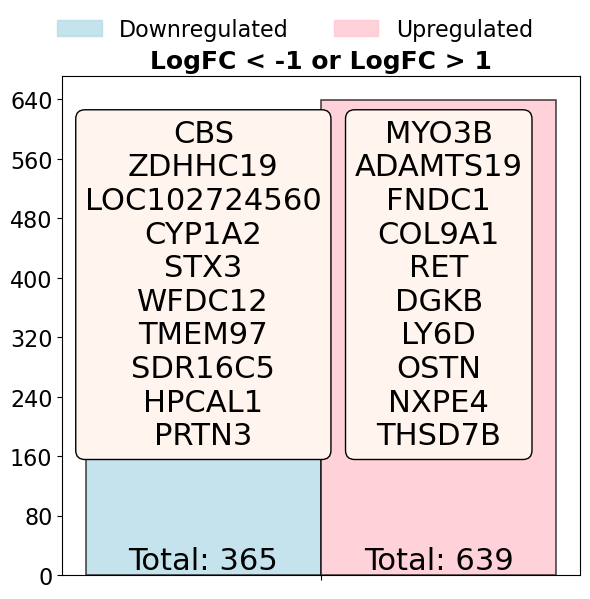

In [14]:
import pandas as pd
import os
import warnings
warnings.filterwarnings('ignore')

def load_and_process_data():
    file_names = ['EdgeR_Significant_IPF.csv']
    current_dir = os.getcwd()
    for file_name in file_names:
        file_path = os.path.join(current_dir, file_name)
        if os.path.exists(file_path):
            print(f'Processing file: {file_name}')
            data = pd.read_csv(file_path)
            all_genes, significant_genes = analyze_gene_data(data)
            new_base_name = file_name.replace('DE_', 'Ranked_DE_')
        else:
            print(f'File not found: {file_name}')
load_and_process_data()


Processing file: DESeq2_Significant_IPF.csv


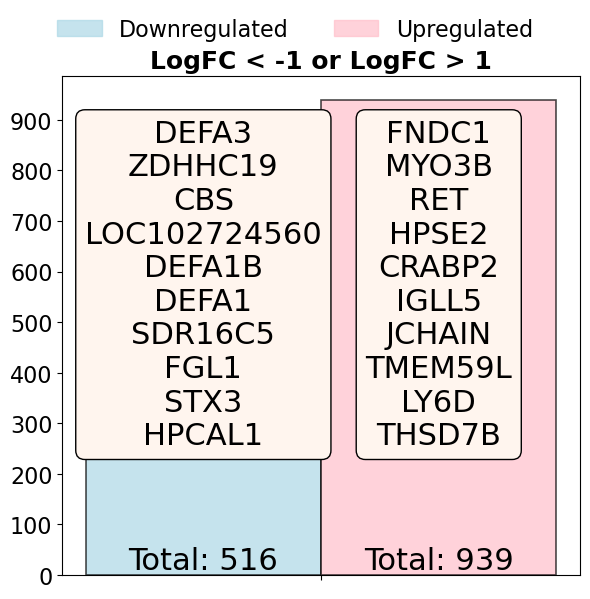

In [15]:
import pandas as pd
import os
import warnings
warnings.filterwarnings('ignore')

def load_and_process_data():
    file_names = ['DESeq2_Significant_IPF.csv']
    current_dir = os.getcwd()
    for file_name in file_names:
        file_path = os.path.join(current_dir, file_name)
        if os.path.exists(file_path):
            print(f'Processing file: {file_name}')
            data = pd.read_csv(file_path)
            all_genes, significant_genes = analyze_gene_data(data)
            new_base_name = file_name.replace('DE_', 'Ranked_DE_')
        else:
            print(f'File not found: {file_name}')
load_and_process_data()


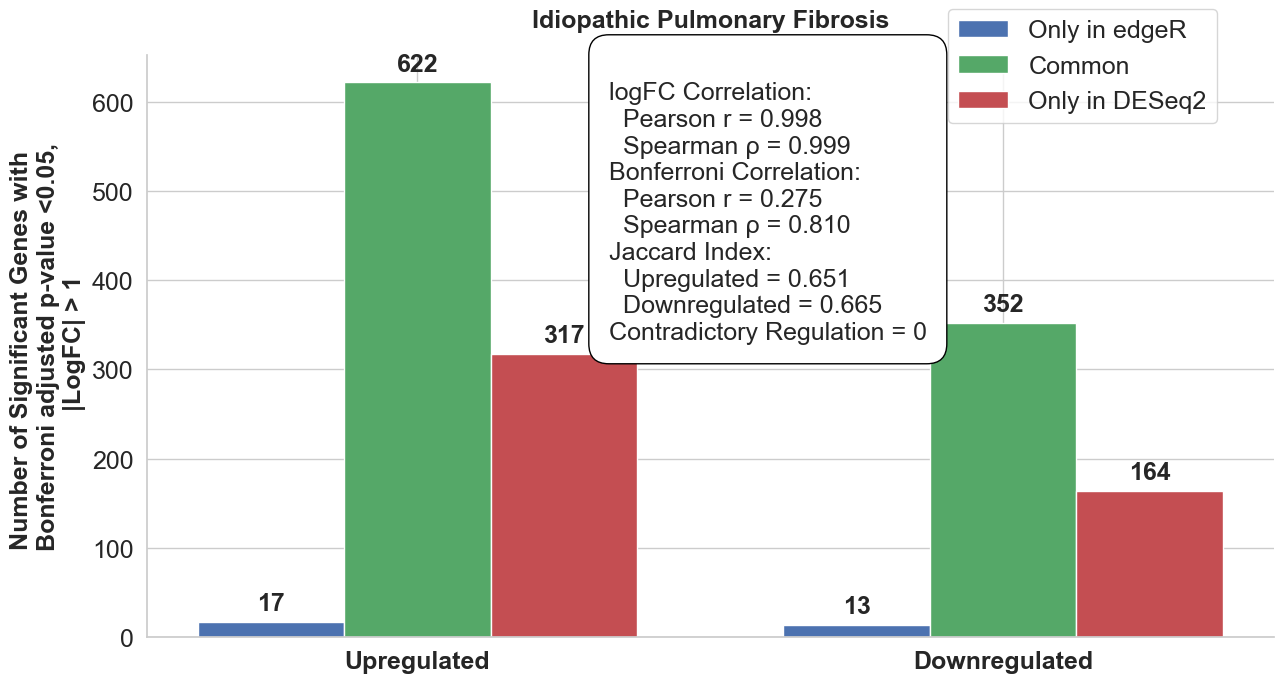

Significant Gene Counts:
  edgeR: 1004
  DESeq2: 1455
  Common: 974

Upregulated Genes:
  Common: 622
  Only in edgeR: 17
  Only in DESeq2: 317
  Jaccard Index: 0.651

Downregulated Genes:
  Common: 352
  Only in edgeR: 13
  Only in DESeq2: 164
  Jaccard Index: 0.665

Contradictory Regulation (Up in one, Down in other): 0

Correlation of logFC:
  Pearson r = 0.998
  Spearman ρ = 0.999

Correlation of Bonferroni-adjusted p-values:
  Pearson r = 0.275
  Spearman ρ = 0.810
Top 10 common_up: ['ABCA12', 'ABCB1', 'ABCB4', 'ABTB3', 'ACY3', 'ADAM23', 'ADAM28', 'ADAMTS14', 'ADAMTS16', 'ADAMTS18']
Top 10 common_down: ['AATK', 'ABCA3', 'ABCC8', 'ABHD5', 'ACADL', 'ACAT2', 'ACOT6', 'ACP3', 'ACSL1', 'ACSM3']
Top 10 edgeR_only_up: ['C22orf42', 'CHGA', 'CHRNB4', 'CLDN19', 'DIPK1C', 'ENTHD1', 'GLRA2', 'GOLGA6L6', 'IL22RA2', 'KCNA7']
Top 10 deseq2_only_up: ['ABCA13', 'ABCG4', 'ABHD12B', 'ABRA', 'ACAN', 'ADAM22', 'ADRA2B', 'ALDH1A3', 'ANKRD18A', 'ANKRD18B']
Top 10 edgeR_only_down: ['FDFT1', 'GCOM1', 'GNA

In [16]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import pearsonr, spearmanr
edgeR_sig_df = pd.read_csv('EdgeR_Significant_IPF.csv').set_index('Gene Symbol')
deseq2_sig_df = pd.read_csv('DESeq2_Significant_IPF.csv').set_index('Gene Symbol')
edgeR_up = set(edgeR_sig_df[edgeR_sig_df['Category'] == 'Upregulated'].index)
edgeR_down = set(edgeR_sig_df[edgeR_sig_df['Category'] == 'Downregulated'].index)
deseq2_up = set(deseq2_sig_df[deseq2_sig_df['Category'] == 'Upregulated'].index)
deseq2_down = set(deseq2_sig_df[deseq2_sig_df['Category'] == 'Downregulated'].index)
common_genes = edgeR_sig_df.index.intersection(deseq2_sig_df.index)
df1 = edgeR_sig_df.loc[common_genes]
df2 = deseq2_sig_df.loc[common_genes]
valid_rows = df1['logFC'].notna() & df2['logFC'].notna() & df1['Bonferroni_adjusted_p-value'].notna() & df2['Bonferroni_adjusted_p-value'].notna() & np.isfinite(df1['logFC']) & np.isfinite(df2['logFC']) & np.isfinite(df1['Bonferroni_adjusted_p-value']) & np.isfinite(df2['Bonferroni_adjusted_p-value'])
df1_clean = df1[valid_rows]
df2_clean = df2[valid_rows]
logfc1 = df1_clean['logFC']
logfc2 = df2_clean['logFC']
bonf1 = df1_clean['Bonferroni_adjusted_p-value']
bonf2 = df2_clean['Bonferroni_adjusted_p-value']
pearson_logfc, _ = pearsonr(logfc1, logfc2)
spearman_logfc, _ = spearmanr(logfc1, logfc2)
pearson_bonf, _ = pearsonr(bonf1, bonf2)
spearman_bonf, _ = spearmanr(bonf1, bonf2)
jaccard_up = len(edgeR_up & deseq2_up) / len(edgeR_up | deseq2_up)
jaccard_down = len(edgeR_down & deseq2_down) / len(edgeR_down | deseq2_down)
contradictory = len(edgeR_up & deseq2_down | edgeR_down & deseq2_up)
common_up = edgeR_up & deseq2_up
common_down = edgeR_down & deseq2_down
edgeR_only_up = edgeR_up - deseq2_up
deseq2_only_up = deseq2_up - edgeR_up
edgeR_only_down = edgeR_down - deseq2_down
deseq2_only_down = deseq2_down - edgeR_down
labels = ['Upregulated', 'Downregulated']
x = np.arange(len(labels))
width = 0.25
edgeR_only_counts = [len(edgeR_only_up), len(edgeR_only_down)]
common_counts = [len(common_up), len(common_down)]
deseq2_only_counts = [len(deseq2_only_up), len(deseq2_only_down)]
sns.set(style='whitegrid')
plt.rcParams.update({'font.size': 12})
colors = {'Only in edgeR': '#4C72B0', 'Common': '#55A868', 'Only in DESeq2': '#C44E52'}
fig, ax = plt.subplots(figsize=(13, 7))
bar1 = ax.bar(x - width, edgeR_only_counts, width, label='Only in edgeR', color=colors['Only in edgeR'])
bar2 = ax.bar(x, common_counts, width, label='Common', color=colors['Common'])
bar3 = ax.bar(x + width, deseq2_only_counts, width, label='Only in DESeq2', color=colors['Only in DESeq2'])
ax.set_ylabel('Number of Significant Genes with \n Bonferroni adjusted p-value <0.05, \n |LogFC| > 1', fontsize=18, weight='bold')
ax.set_title('Idiopathic Pulmonary Fibrosis', fontsize=18, weight='bold', pad=20)
ax.set_xticks(x)
ax.set_xticklabels(labels, fontsize=18, weight='bold')
ax.tick_params(axis='y', labelsize=18)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.legend(frameon=True, fontsize=18, loc='upper left', bbox_to_anchor=(0.7, 1.1))
for bars in [bar1, bar2, bar3]:
    for bar in bars:
        height = bar.get_height()
        ax.annotate(f'{int(height)}', xy=(bar.get_x() + bar.get_width() / 2, height), xytext=(0, 5), textcoords='offset points', ha='center', va='bottom', fontsize=18, weight='bold')
textstr = f'\nlogFC Correlation:\n  Pearson r = {pearson_logfc:.3f}\n  Spearman ρ = {spearman_logfc:.3f}\nBonferroni Correlation:\n  Pearson r = {pearson_bonf:.3f}\n  Spearman ρ = {spearman_bonf:.3f}\nJaccard Index:\n  Upregulated = {jaccard_up:.3f}  \n  Downregulated = {jaccard_down:.3f}\nContradictory Regulation = {contradictory}'
props = dict(boxstyle='round,pad=0.8', facecolor='white', edgecolor='black')
ax.text(0.41, 1, textstr, transform=ax.transAxes, fontsize=18, verticalalignment='top', bbox=props)
plt.tight_layout()
plt.show()
common_up = edgeR_up & deseq2_up
common_down = edgeR_down & deseq2_down
edgeR_only_up = edgeR_up - deseq2_up
deseq2_only_up = deseq2_up - edgeR_up
edgeR_only_down = edgeR_down - deseq2_down
deseq2_only_down = deseq2_down - edgeR_down
print('Significant Gene Counts:')
print(f'  edgeR: {edgeR_sig_df.shape[0]}')
print(f'  DESeq2: {deseq2_sig_df.shape[0]}')
print(f'  Common: {len(common_genes)}')
print('\nUpregulated Genes:')
print(f'  Common: {len(common_up)}')
print(f'  Only in edgeR: {len(edgeR_only_up)}')
print(f'  Only in DESeq2: {len(deseq2_only_up)}')
print(f'  Jaccard Index: {jaccard_up:.3f}')
print('\nDownregulated Genes:')
print(f'  Common: {len(common_down)}')
print(f'  Only in edgeR: {len(edgeR_only_down)}')
print(f'  Only in DESeq2: {len(deseq2_only_down)}')
print(f'  Jaccard Index: {jaccard_down:.3f}')
print(f'\nContradictory Regulation (Up in one, Down in other): {contradictory}')
print('\nCorrelation of logFC:')
print(f'  Pearson r = {pearson_logfc:.3f}')
print(f'  Spearman ρ = {spearman_logfc:.3f}')
print('\nCorrelation of Bonferroni-adjusted p-values:')
print(f'  Pearson r = {pearson_bonf:.3f}')
print(f'  Spearman ρ = {spearman_bonf:.3f}')
common_up = sorted(list(edgeR_up & deseq2_up))
common_down = sorted(list(edgeR_down & deseq2_down))
edgeR_only_up = sorted(list(edgeR_up - deseq2_up))
deseq2_only_up = sorted(list(deseq2_up - edgeR_up))
edgeR_only_down = sorted(list(edgeR_down - deseq2_down))
deseq2_only_down = sorted(list(deseq2_down - edgeR_down))
print('Top 10 common_up:', common_up[:10])
print('Top 10 common_down:', common_down[:10])
print('Top 10 edgeR_only_up:', edgeR_only_up[:10])
print('Top 10 deseq2_only_up:', deseq2_only_up[:10])
print('Top 10 edgeR_only_down:', edgeR_only_down[:10])
print('Top 10 deseq2_only_down:', deseq2_only_down[:10])


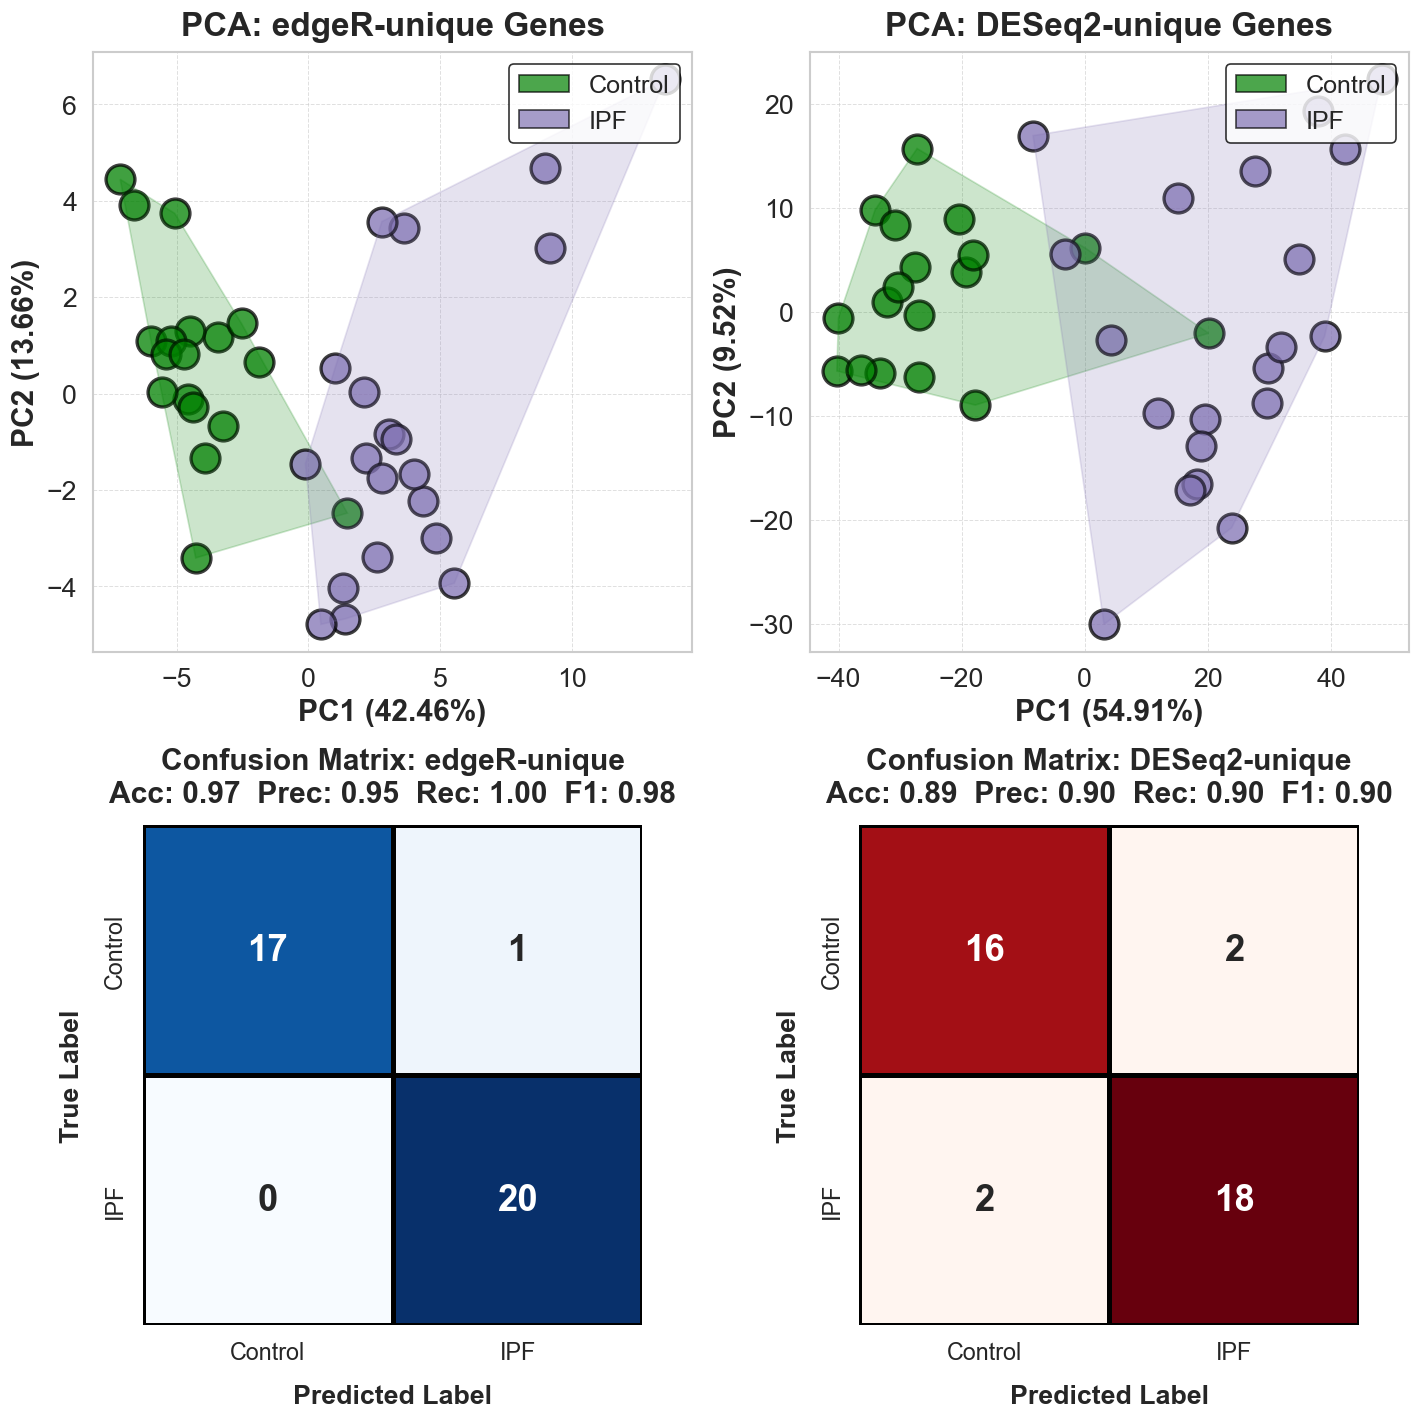

edgeR-unique Metrics
Accuracy:  0.974
Precision: 0.952
Recall:    1.000
F1 Score:  0.976
------------------------------
DESeq2-unique Metrics
Accuracy:  0.895
Precision: 0.900
Recall:    0.900
F1 Score:  0.900


In [17]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import confusion_matrix
from matplotlib.patches import Patch
from scipy.spatial import ConvexHull
from matplotlib import gridspec
import seaborn as sns

def prepare_data(gene_list, df):
    data = df.copy()
    filtered_genes = [g for g in gene_list if g in data.index]
    data = data.loc[filtered_genes]
    data_transposed = np.log2(data.transpose() + 1)
    group_names = ['Control' if 'Normal' in s else 'IPF' for s in data_transposed.index]
    labels = [0 if g == 'Control' else 1 for g in group_names]
    return (data_transposed, labels, group_names)

def plot_pca(ax, data_scaled, group_names, title, color_map):
    pca = PCA(n_components=2)
    components = pca.fit_transform(data_scaled)
    explained = pca.explained_variance_ratio_
    explained_text = [f'{v:.2%}' for v in explained]
    df = pd.DataFrame(components, columns=['PC1', 'PC2'])
    df['Group'] = group_names
    for label in df['Group'].unique():
        points = df[df['Group'] == label][['PC1', 'PC2']].values
        ax.scatter(points[:, 0], points[:, 1], s=300, color=color_map[label], label=label, edgecolor='black', alpha=0.75, linewidth=2)
        if len(points) > 2:
            hull = ConvexHull(points)
            hull_pts = points[hull.vertices]
            ax.fill(hull_pts[:, 0], hull_pts[:, 1], color=color_map[label], alpha=0.2)
    ax.set_title(title, fontsize=20, weight='bold', pad=10)
    ax.set_xlabel(f'PC1 ({explained_text[0]})', fontsize=18, weight='bold')
    ax.set_ylabel(f'PC2 ({explained_text[1]})', fontsize=18, weight='bold')
    ax.tick_params(axis='both', labelsize=16, width=2)
    ax.grid(True, linestyle='--', linewidth=0.6, alpha=0.6)
    handles = [Patch(facecolor=color_map[l], edgecolor='black', label=l, alpha=0.7) for l in df['Group'].unique()]
    ax.legend(handles=handles, fontsize=15, frameon=True, edgecolor='black', loc='upper right')
    return components
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

def plot_conf_matrix(ax, cm, title, cmap, class_labels, y_true, y_pred):
    sns.heatmap(cm, annot=True, fmt='d', cmap=cmap, cbar=False, xticklabels=class_labels, yticklabels=class_labels, linewidths=2, linecolor='black', square=True, ax=ax, annot_kws={'size': 22, 'weight': 'bold'})
    acc = accuracy_score(y_true, y_pred)
    prec = precision_score(y_true, y_pred)
    rec = recall_score(y_true, y_pred)
    f1 = f1_score(y_true, y_pred)
    metrics_title = f'{title}\nAcc: {acc:.2f}  Prec: {prec:.2f}  Rec: {rec:.2f}  F1: {f1:.2f}'
    ax.set_title(metrics_title, fontsize=18, fontweight='bold', pad=14)
    ax.set_xlabel('Predicted Label', fontsize=16, fontweight='bold', labelpad=12)
    ax.set_ylabel('True Label', fontsize=16, fontweight='bold', labelpad=12)
    ax.tick_params(axis='both', labelsize=14, width=2)
color_map = {'Control': 'green', 'IPF': 'm'}
data_scaled_er, labels_er, group_names_er = prepare_data(edgeR_only_up + edgeR_only_down, Normal_IPF)
data_scaled_dq, labels_dq, group_names_dq = prepare_data(deseq2_only_up + deseq2_only_down, Normal_IPF)
fig = plt.figure(figsize=(12, 12), dpi=120)
gs = gridspec.GridSpec(2, 2, height_ratios=[1.2, 1])
ax1 = fig.add_subplot(gs[0, 0])
components_er = plot_pca(ax1, data_scaled_er, group_names_er, 'PCA: edgeR-unique Genes', color_map)
ax2 = fig.add_subplot(gs[0, 1])
components_dq = plot_pca(ax2, data_scaled_dq, group_names_dq, 'PCA: DESeq2-unique Genes', color_map)
clf_er = LogisticRegression().fit(components_er, labels_er)
preds_er = clf_er.predict(components_er)
cm_er = confusion_matrix(labels_er, preds_er)
clf_dq = LogisticRegression().fit(components_dq, labels_dq)
preds_dq = clf_dq.predict(components_dq)
cm_dq = confusion_matrix(labels_dq, preds_dq)
ax3 = fig.add_subplot(gs[1, 0])
plot_conf_matrix(ax3, cm_er, 'Confusion Matrix: edgeR-unique', cmap='Blues', class_labels=['Control', 'IPF'], y_true=labels_er, y_pred=preds_er)
ax4 = fig.add_subplot(gs[1, 1])
plot_conf_matrix(ax4, cm_dq, 'Confusion Matrix: DESeq2-unique', cmap='Reds', class_labels=['Control', 'IPF'], y_true=labels_dq, y_pred=preds_dq)
plt.tight_layout()
plt.show()
acc_er = accuracy_score(labels_er, preds_er)
prec_er = precision_score(labels_er, preds_er)
rec_er = recall_score(labels_er, preds_er)
f1_er = f1_score(labels_er, preds_er)
print('edgeR-unique Metrics')
print(f'Accuracy:  {acc_er:.3f}')
print(f'Precision: {prec_er:.3f}')
print(f'Recall:    {rec_er:.3f}')
print(f'F1 Score:  {f1_er:.3f}')
print('-' * 30)
acc_dq = accuracy_score(labels_dq, preds_dq)
prec_dq = precision_score(labels_dq, preds_dq)
rec_dq = recall_score(labels_dq, preds_dq)
f1_dq = f1_score(labels_dq, preds_dq)
print('DESeq2-unique Metrics')
print(f'Accuracy:  {acc_dq:.3f}')
print(f'Precision: {prec_dq:.3f}')
print(f'Recall:    {rec_dq:.3f}')
print(f'F1 Score:  {f1_dq:.3f}')
